# EDA — Route Feasibility Dataset

Explores `data/processed/route_dataset.csv`: class balance, feature distributions, label noise, and the 'hard segment' where models differ.

In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
plt.rcParams['figure.dpi'] = 120
df = pd.read_csv('../data/processed/route_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Positive rate: {df.feasible.mean():.2%}')
df.head()

Shape: (50000, 10)
Positive rate: 25.05%


,variant,manufacturer,range_km,twin_engine,etops_capable,origin_iata,dest_iata,distance_km,payload_proxy,feasible
0,A320,Airbus,6150,True,True,BXU,NYO,10198.146659,0.478851,0
1,Tu-154,Tupolev,5280,True,True,AFA,CLV,2713.551694,0.283885,1
2,DC-6,Douglas,4835,False,False,EOZ,HOT,3886.285889,0.222113,1
3,DR-400,Robin,1450,False,False,GOO,JHG,7730.425850,0.844015,0
4,ATR-42,ATR,1555,True,False,HER,PLO,13839.293237,0.305077,0


## Class Balance

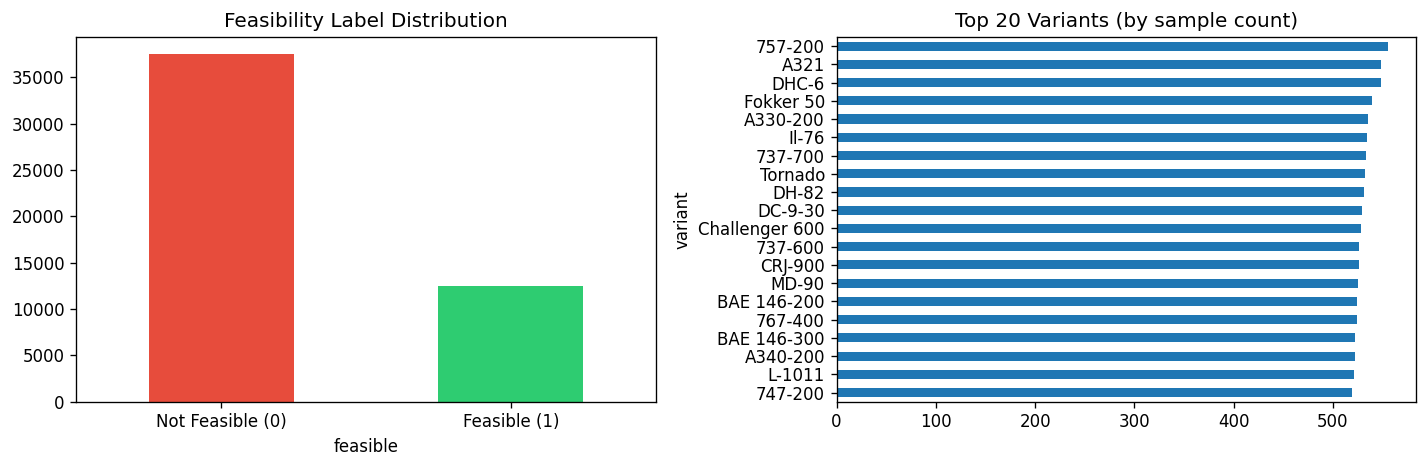

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['feasible'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Feasibility Label Distribution'); axes[0].set_xticklabels(['Not Feasible (0)', 'Feasible (1)'], rotation=0)
df['variant'].value_counts().head(20).plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 20 Variants (by sample count)'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## Feature Distributions

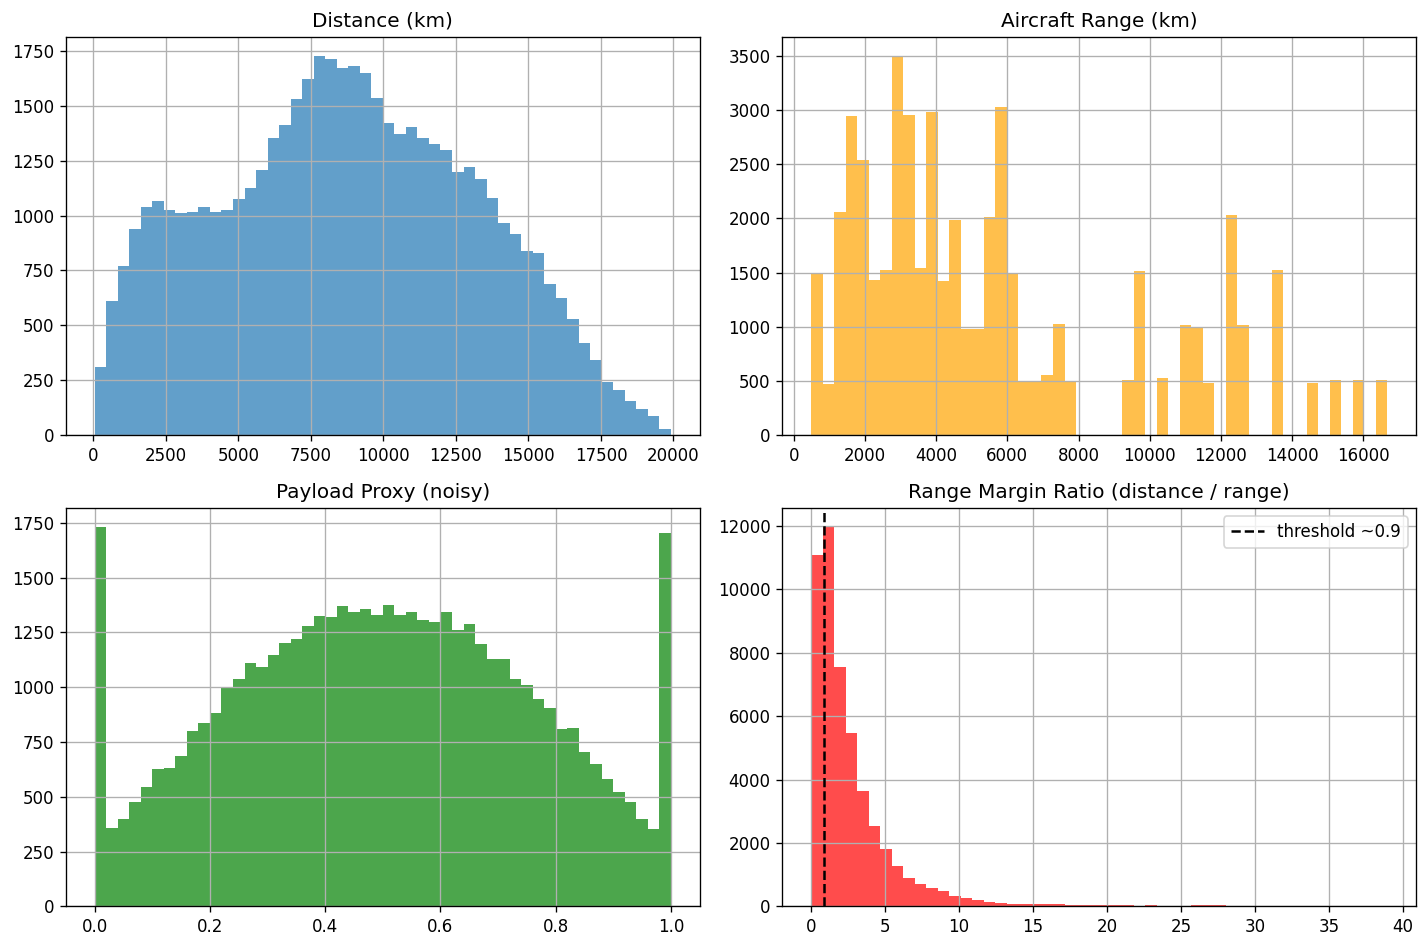

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df['distance_km'].hist(bins=50, ax=axes[0,0], alpha=0.7); axes[0,0].set_title('Distance (km)')
df['range_km'].hist(bins=50, ax=axes[0,1], alpha=0.7, color='orange'); axes[0,1].set_title('Aircraft Range (km)')
df['payload_proxy'].hist(bins=50, ax=axes[1,0], alpha=0.7, color='green'); axes[1,0].set_title('Payload Proxy (noisy)')
(df['distance_km'] / df['range_km']).hist(bins=50, ax=axes[1,1], alpha=0.7, color='red')
axes[1,1].set_title('Range Margin Ratio (distance / range)'); axes[1,1].axvline(0.9, color='k', ls='--', label='threshold ~0.9')
axes[1,1].legend()
plt.tight_layout(); plt.show()

## Hard Segment

Routes where `distance/range` is in [0.7, 1.1] — the interesting band where payload, headwind, and ETOPS actually matter.

In [4]:
df['margin'] = df['distance_km'] / df['range_km']
df['segment'] = pd.cut(df['margin'], bins=[0, 0.3, 0.7, 1.1, 5], labels=['trivial_yes', 'easy', 'hard', 'trivial_no'])
seg = df.groupby('segment').agg(n=('feasible', 'count'), pos_rate=('feasible', 'mean')).round(3)
print(seg)
print(f'\nHard segment: {(df.segment=="hard").mean():.1%} of all samples')

                 n  pos_rate
segment                     
trivial_yes   3072     0.971
easy          6510     0.972
hard          7096     0.312
trivial_no   26378     0.030

Hard segment: 14.2% of all samples


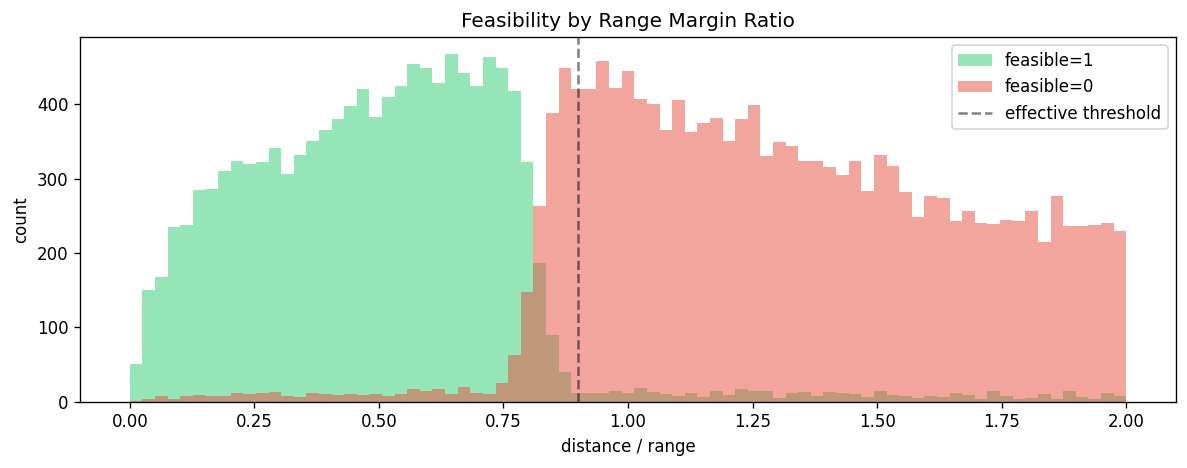

In [5]:
# Feasibility by margin — shows the soft boundary
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(0, 2, 80)
for label, color in [(1, '#2ecc71'), (0, '#e74c3c')]:
    sub = df[df.feasible == label]
    ax.hist(sub['margin'], bins=bins, alpha=0.5, label=f'feasible={label}', color=color)
ax.axvline(0.9, color='k', ls='--', alpha=0.5, label='effective threshold')
ax.set_xlabel('distance / range'); ax.set_ylabel('count'); ax.set_title('Feasibility by Range Margin Ratio')
ax.legend(); plt.tight_layout(); plt.show()

## Feature Correlations

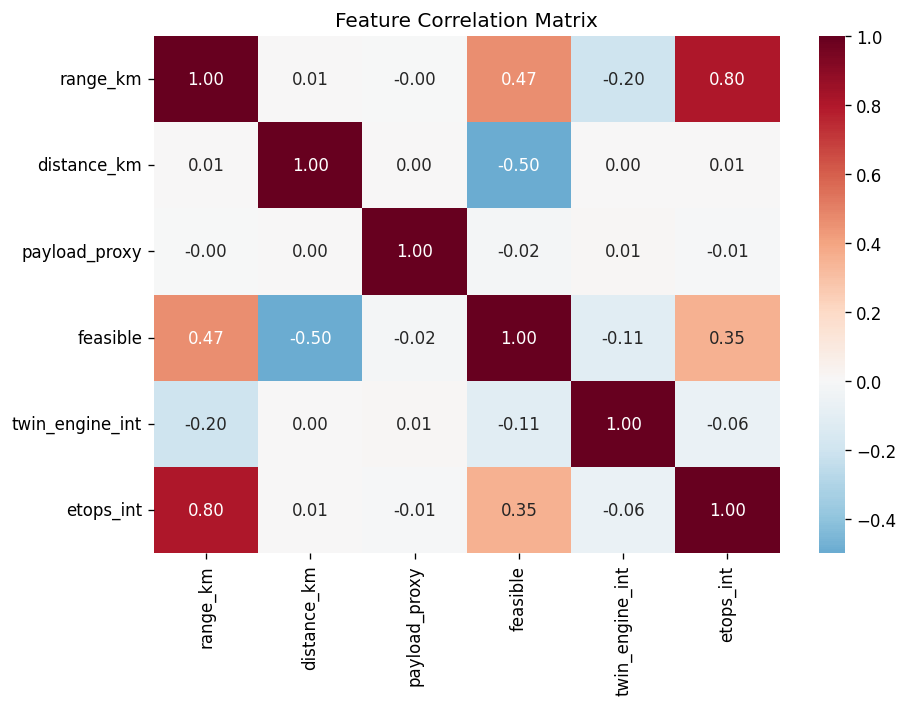

In [6]:
numeric_cols = ['range_km', 'distance_km', 'payload_proxy', 'feasible']
df['twin_engine_int'] = df['twin_engine'].astype(int)
df['etops_int'] = df['etops_capable'].astype(int)
corr = df[numeric_cols + ['twin_engine_int', 'etops_int']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix'); plt.tight_layout(); plt.show()

## Key Findings

- **25% positive class** — imbalanced but not extreme; stratified splitting handles this.
- **Range margin ratio** is the dominant signal (corr ≈ -0.7 with feasibility).
- **Hard segment** (~30% of data) is where models actually need to learn — the rest is trivially separable.
- **Payload proxy** adds meaningful noise — the model cannot perfectly predict feasibility because it doesn't observe the true payload or headwind.